In [1]:
#  import libraries
import h5py
import os, sys
import zipfile
import numpy as np
from mpi4py import MPI
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# --- Configuration ---
from ICESEE.config._utility_imports import *
from ICESEE.src.utils.tools import get_grid_dimensions, midprofiles_coords, midpoint_rect, midindices

[ICESEE] Running in Jupyter - disabling command line arguments


In [2]:
results_dir = "results"


# cwd = os.getcwd()
# data_dir='_data/_modelrun_datasets'
# cwd = 'cluster_data';data_dir='cluster_data/_modelrun_datasets';  results_dir = "cluster_data/results"
cwd = os.getcwd(); data_dir='_modelrun_datasets'
# cwd = 'test_data_working';  data_dir='test_data_working_0/test'
# cwd = 'test_1'; data_dir='test_1'

In [3]:
parameters = load_yaml_to_dict(f'{cwd}/params.yaml')
enkf_params     = get_section(parameters, 'enkf-parameters')
modeling_params = get_section(parameters, 'modeling-parameters')

In [21]:
# Path to the ZIP file
# check if .zip file exists
# if not os.path.exists("results.zip"):
#     print("The file 'results.zip' does not exist.")
#     sys.exit()
    
# zip_file_path = "results.zip"
# # zip_file_path = "results_loc_joint.zip"
# output_folder = "results"

# # Unzip the file
# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         # Create the output folder if it doesn't exist
#         if not os.path.exists(output_folder):
#             os.makedirs(output_folder)
#         zip_ref.extractall(output_folder)
#     print(f"Extracted '{zip_file_path}' to '{output_folder}'")
# else:
#     print(f"The file '{zip_file_path}' does not exist.")


In [22]:
# results_dir = "results"
filter_type = "true-wrong"
file_path = f"{results_dir}/{filter_type}-issm.h5"
datasets_tw = extract_datasets_from_h5(file_path)
t=datasets_tw['t']
# ensemble_true_state = datasets_tw['ensemble_true_state']
# ensemble_nurged_state = datasets_tw['ensemble_nurged_state']
# w = datasets_tw['w']
ind_m = datasets_tw['obs_index']
tm_m = datasets_tw['obs_max_time'][0]
run_mode = datasets_tw['run_mode'][0]

t= np.linspace(modeling_params.get('tinitial'), modeling_params.get('num_years'), int((modeling_params.get('num_years') - modeling_params.get('tinitial'))/modeling_params.get('timesteps_per_year'))+1)
kwargs={'t':t}
tm_m=np.array([enkf_params["obs_max_time"]])
obs_t, ind_m, num_observations = UtilsFunctions(enkf_params).generate_observation_schedule(**kwargs)
print(ind_m, ind_m.shape)
print(obs_t, obs_t.shape)

[ICESEE] Reading data from results/true-wrong-issm.h5...
[ICESEE] Dataset 'Lxy' extracted with shape (2,)
[ICESEE] Dataset 'b_io' extracted with shape (2,)
[ICESEE] Dataset 'nxy' extracted with shape (2,)
[ICESEE] Dataset 'obs_index' extracted with shape (27,)
[ICESEE] Dataset 'obs_max_time' extracted with shape (1,)
[ICESEE] Dataset 'run_mode' extracted with shape (1,)
[ICESEE] Dataset 't' extracted with shape (501,)
[ICESEE] Data extraction complete.
[  0  15  30  45  60  75  90 105 120 135 150 165 180 195 210 225 240 255
 270 285 300 315 330 345 360 375 390] (27,)
[ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27. 30. 33. 36. 39. 42. 45. 48. 51.
 54. 57. 60. 63. 66. 69. 72. 75. 78.] (27,)


In [23]:
filter_type = "EnKF"
if run_mode != 0:
    file_path = f"{results_dir}/{filter_type}-issm.h5"
    datasets = extract_datasets_from_h5(file_path)
    ensemble_vec_full = datasets["ensemble_vec_full"]
    ensemble_vec_mean = datasets["ensemble_vec_mean"] 
    ensemble_bg       = datasets["ensemble_bg"]
else:
    # file_path = '_modelrun_datasets/icesee_ensemble_data.h5'
    file_path = f'{data_dir}/icesee_ensemble_data.h5'
    with h5py.File(file_path, 'r') as f:
        ensemble_vec_full = f['ensemble'][:]
        ensemble_vec_mean = f['ensemble_mean'][:]
        # ensemble_true_state = f['true_state'][:]
        # ensemble_nurged_state = f['nurged_state'][:]
        ensemble_bg = None
nd, Nens, nt = ensemble_vec_full.shape
ndim = nd//6

In [24]:
# file_path = f'{data_dir}/icesee_ensemble_data.h5'

# di      = 0.8930
# rho_ice = 917.0
# rho_sw  = 1028.0
# nt = 24

# with h5py.File(file_path, 'r+') as f:
#     ens_dset  = f['ensemble']        # shape: (nstate, nens, nt)
#     mean_dset = f['ensemble_mean']   # shape: (nstate, nt)

#     for t_id in range(nt):
#         # ---- load all ensembles at this time step (single I/O read) ----
#         vecs = ens_dset[:, :, t_id]            # np.ndarray (nstate, nens)

#         # Slices as views into vecs
#         thickness = vecs[0*ndim:1*ndim, :]     # (ndim, nens)
#         surface   = vecs[1*ndim:2*ndim, :]     # (ndim, nens)
#         # vecs[2*ndim:4*ndim, :]  # other fields (e.g., velocity) left untouched
#         bed       = vecs[4*ndim:5*ndim, :]     # (ndim, nens)

#         # ---- physics / geometry updates ----

#         # Enforce minimum thickness
#         np.maximum(thickness, 1.0, out=thickness)

#         ocean_levelset = thickness + bed / di

#         floating_mask  = ocean_levelset < 0    # boolean (ndim, nens)
#         grounded_mask  = ~floating_mask

#         # Floating ice: update surface from hydrostatic condition
#         surface[floating_mask] = (
#             thickness[floating_mask] * ((rho_sw - rho_ice) / rho_sw)
#         )

#         # Base before enforcing bed constraint
#         base = surface - thickness             # new array (ndim, nens)

#         # Base cannot be below bed: base = max(base, bed)
#         below_bed = base < bed
#         base[below_bed] = bed[below_bed]

#         # Grounded ice: base = bed
#         base[grounded_mask] = bed[grounded_mask]

#         # Update surface = base + thickness
#         surface[:, :] = base + thickness

#         thickness[:, :] = surface - base

#         # ---- write back this time slice (single I/O write) ----
#         ens_dset[0*ndim:1*ndim, :, t_id] = thickness
#         ens_dset[1*ndim:2*ndim, :, t_id] = surface

#         # ---- ensemble mean at this time step (no extra HDF5 read) ----
#         # mean over ensemble axis (axis=1)
#         mean_dset[:, t_id] = np.mean(ens_dset[:, :, t_id], axis=1)

In [25]:
# for t_id in range(nt):
#     for ens in range(Nens):
#         with h5py.File(f'{data_dir}/icesee_ensemble_data.h5', 'r') as f:
#             # ensemble_vec_full = f['ensemble'][:]
#             ens_vec = f['ensemble'][:,ens,t_id]
#             thickness = ens_vec[:ndim]
#             surface = ens_vec[ndim:2*ndim]
#             bed = ens_vec[4*ndim:5*ndim]

#             pos = np.where(thickness<1)
#             thickness[pos] = 1.0

#             di = 0.8930
#             rho_ice = 917.0
#             rho_sw = 1028.0

#             ocean_levelset = thickness + (bed/di)
#             # Floating ice (ocean_levelset < 0) find the indices
#             pos = np.where(ocean_levelset < 0)
#             surface[pos] = thickness[pos]* ((rho_sw - rho_ice)/rho_sw)
#             base = surface - thickness

#             pos_base = np.where(base < bed)
#             base[pos_base] = base[pos_base]

#             # grounded ice
#             pos_grounded = np.where(ocean_levelset >= 0)
#             base[pos_grounded] = bed[pos_grounded]

#             # update surface
#             surface = base + thickness

#         with h5py.File(f'{data_dir}/icesee_ensemble_data.h5', 'a') as f:
#             # _dset = f['ensemble'][:]
#             dset = f['ensemble'][:,ens,t_id]
#             dset[:ndim] = thickness
#             dset[ndim:2*ndim] = surface
#             dset[4*ndim:5*ndim] = bed
            
#     # each timestep compute the ensemble mean
#     with h5py.File(f'{data_dir}/icesee_ensemble_data.h5', 'r') as f:
#         # _dset = f['ensemble'][:]
#         dset = f['ensemble'][:,:,t_id]
#         ens_mean = np.mean(dset,axis=1)

#     # each timestep compute the ensemble mean
#     with h5py.File(f'{data_dir}/icesee_ensemble_data.h5', 'a') as f:
#         ensemble_vec_mean = f['ensemble_mean']
#         ensemble_vec_mean[:,t_id] = ens_mean
            

In [26]:
file_path = f'{data_dir}/icesee_ensemble_data.h5'
with h5py.File(file_path, 'r') as f:
    ensemble_vec_full = f['ensemble'][:]
    ensemble_vec_mean = f['ensemble_mean'][:]

In [27]:
# file_path='_modelrun_datasets/true_nurged_states.h5'
with h5py.File(f'{data_dir}/true_nurged_states.h5', 'r') as f:
    ensemble_true_state = f['true_state'][:]
    ensemble_nurged_state = f['nurged_state'][:]

with h5py.File(f'{data_dir}/synthetic_obs.h5','r') as f:
    w = f['hu_obs'][:]
     # print(f["true_state"])
w.shape

(20082, 27)

In [28]:
ndim = w.shape[0]//6
print(w[4*ndim:5*ndim,:].min(), w[4*ndim:5*ndim,:].max())

-1333.1190603326147 494.0292291146971


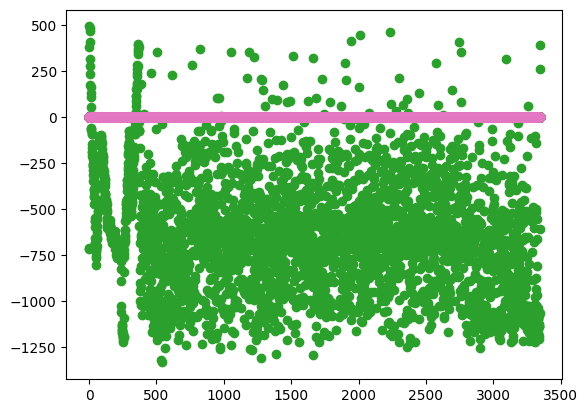

In [29]:
# plot bed observations
plt.plot(w[4*ndim:5*ndim,:], 'o')
plt.show()

In [30]:
# update the mean
# ensemble_vec_mean[:,0] = ensemble_nurged_state[:,0]

In [31]:
# Construct global observation indices for the reduced vector
from ICESEE.src.utils.tools import icesee_get_index
params = {"total_state_param_vars": 6, 'default_run': 1}
model_kwargs = {
    'all_observed': ['Surface','Vx','Vy'],
    'vec_inputs': ['Thickness', 'Surface','Vx','Vy','bed','coefficient'],
    'nd': ensemble_vec_full.shape[0],
    'params': params,
    'dim_list': [ensemble_vec_full.shape[0]],
}
vecs, indx_map, dim_per_proc = icesee_get_index(**model_kwargs)
all_observed = ['Surface','Vx','Vy']
obs_indices = np.concatenate([indx_map[key] for key in all_observed])

# Now reduce the observations consistently
# w = w[obs_indices, :]
w = w[:, :ind_m.shape[0]]  # only use the observations at the observation indices
w.shape

(20082, 27)

Midpoint indices ix = 57, iy = 14
At h_indx = 819 profile 
(27,) (20082, 27) (27,)


Text(0.5, 1.0, 'middle profile at h_indx = 3345')

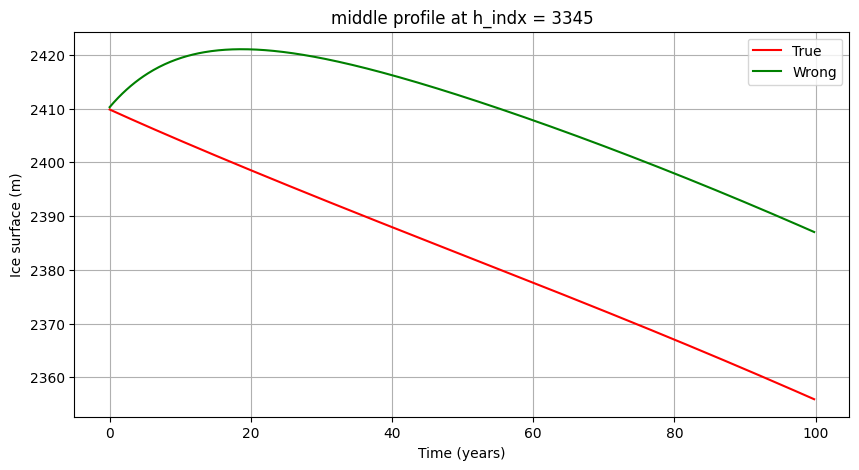

In [32]:
nt = ensemble_true_state.shape[1]; num_steps = nt-1
ndim = ensemble_true_state.shape[0]
hdim = ndim//6 # [h,u,v,bed,f]

Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]
mx,my = get_grid_dimensions(nx,ny,hdim)
# lets get the middle index
# vert_prof, horiz_prof = midprofiles_coords(mx,my,hdim)
# print(f"Vertical profile at x = {vert_prof}, Horizontal profile at y = {horiz_prof}")
ix,iy= midindices(mx,my)
print(f"Midpoint indices ix = {ix}, iy = {iy}")

# define profile flag
profile_flag = "middle" # begining, middle, end, random

if profile_flag == "begining":
    h_indx = 0 # first profile
elif profile_flag == "middle":
    # h_indx = ix*iy # middle profile
    # h_indx = ix*iy + iy//2
    # h_indx = (ix*(my-1)) + (my-1)//2
    # h_indx = ix*(my-1) + 0
    h_indx = ((ix//2)*(my-1)) + (iy)//2 #(ix/2,iy/2) point
elif profile_flag == "end":
    h_indx = (mx-1)*(my-1) + 0
    # h_indx = (mx-1)*(my-1) + (my-1)//2
# elif profile_flag == "random":
#     h_indx = np.random.randint(htrue.shape[0])

print(f"At h_indx = {h_indx} profile ")

# plot the ensemble_true_state and ensemble_nurged_state
htrue = ensemble_true_state[hdim:2*hdim,:]
hnurge = ensemble_nurged_state[hdim:2*hdim,:]

# h_indx=hdim-2
# h_indx=0
h_indx = hdim-2

h_true = htrue[h_indx,:]
h_nurged = hnurge[h_indx,:]

plt.figure(figsize=(10,5))
plt.plot(t[:-1],h_true[:-1],'r',label='True')
plt.plot(t[:-1],h_nurged[:-1],'g',label='Wrong')
obs = w[hdim+h_indx,:]; print(obs.shape, w.shape, t[ind_m].shape)
# plt.plot(t[ind_m],obs,'kx',label="Observations")
plt.xlabel('Time (years)')
plt.ylabel('Ice surface (m)')
plt.legend()
plt.grid()
plt.title(f"{profile_flag} profile at h_indx = {h_indx}")

In [33]:
print(f"{h_true[:-1].shape} with t: {t[:-1].shape}")
hdim
# 0.25*hdim

(500,) with t: (500,)


3347

In [34]:
Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]

In [35]:
# h_indx = ix * my + ((my-1) // 2)
# Assuming a nodal grid
row, col = h_indx // (my-1), h_indx % (mx-1)
dx, dy = Lx/(my-1), Ly/(mx-1)
x_h,y_h = col*dx, row*dy

dx,dy = Lx/(mx-1), Ly/(mx-1)
# x_h,y_h = (col+0.5)*dx, (row+0.5)*dy

print(f"At h_indx = {h_indx}, x = {x_h}, y = {y_h}")

At h_indx = 3345, x = 860689.6551724138, y = 80701.75438596492


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# General helpers
# ------------------------------------------------------------
def style_axis(ax, ylabel=None, xlabel=None):
    """Apply consistent styling to a single axis."""
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=16, fontweight="bold")
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=16, fontweight="bold")

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(labelsize=14)

    # make tick labels bold and integer-valued
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels([f"{int(x)}" for x in xticks], fontweight="bold")
    ax.set_yticklabels([f"{int(y)}" for y in yticks], fontweight="bold")


def plot_scalar_block(
    ax,
    t,
    _nt,
    hdim,
    block_id,            # 0, 1, 2, ... (block index in state)
    h_indx,              # spatial index within block
    w,
    ensemble_true_state,
    ensemble_nurged_state,
    ensemble_vec_mean,
    ensemble_vec_full,
    Nens,
    filter_type,
    ylabel,
    obs_times_idx=None,  # e.g. ind_m for observation times (or None)
    obs_mask_zero=False, # mask out zeros in w
    obs_label="Observations"
):
    """
    Generic panel for a scalar field stored in one block of length hdim.

    block_id = 0 -> indices [0 : hdim]
    block_id = 1 -> indices [hdim : 2*hdim]
    etc.
    """
    base = block_id * hdim
    state_idx = base + h_indx

    # observations for this variable, if any
    if obs_times_idx is not None:
        obs_vals = w[state_idx, :]
        if obs_mask_zero:
            mask = obs_vals != 0
            t_obs = t[obs_times_idx][mask]
            y_obs = obs_vals[mask]
        else:
            t_obs = t[obs_times_idx]
            y_obs = obs_vals
    else:
        t_obs = None
        y_obs = None

    # extract from state arrays
    true_block     = ensemble_true_state[base:base + hdim, :]
    nurged_block   = ensemble_nurged_state[base:base + hdim, :]
    ens_mean_block = ensemble_vec_mean[base:base + hdim, :]
    ens_full_block = ensemble_vec_full[base:base + hdim, :, :]  # (hdim, Nens, Nt)

    y_true     = true_block[h_indx, :]
    y_nurged   = nurged_block[h_indx, :]
    y_ens_mean = ens_mean_block[h_indx, :]

    y_ens_mem = ens_full_block[h_indx, :, :].T  # (Nt, Nens)

    # ensemble members
    for ens in range(Nens):
        ax.plot(
            t[:_nt], y_ens_mem[:_nt, ens],
            lw=0.5, color="gray",
            label=f"{filter_type}" if ens == 0 else ""
        )

    # mean / truth / wrong
    ax.plot(t[:_nt], y_true[:_nt],   "--r", label="True",  linewidth=2)
    ax.plot(t[:_nt], y_nurged[:_nt], "--g", label="Wrong", linewidth=2)
    ax.plot(t[:_nt], y_ens_mean[:_nt], "--b",
            label=f"{filter_type} mean", linewidth=2)

    # observations
    if t_obs is not None and y_obs is not None:
        ax.plot(t_obs[1:], y_obs[1:], "kx", label=obs_label, markersize=8)

    ax.legend(prop={"size": 12, "weight": "bold"})
    style_axis(ax, ylabel=ylabel)


def plot_velocity_block(
    ax,
    t,
    _nt,
    hdim,
    block_id_u,          # block index for u
    block_id_v,          # block index for v
    h_indx,
    w,
    ensemble_true_state,
    ensemble_nurged_state,
    ensemble_vec_mean,
    ensemble_vec_full,
    Nens,
    filter_type,
    ylabel,
    obs_times_idx=None,
    obs_label="Observations"
):
    """
    Specialized panel for velocity magnitude from u, v blocks.
    """
    base_u = block_id_u * hdim
    base_v = block_id_v * hdim
    idx_u = base_u + h_indx
    idx_v = base_v + h_indx

    # observations
    if obs_times_idx is not None:
        obs_u = w[idx_u, :]
        obs_v = w[idx_v, :]
        obs_mag = np.sqrt(obs_u**2 + obs_v**2)
        t_obs = t[obs_times_idx]
        y_obs = obs_mag
    else:
        t_obs = None
        y_obs = None

    # true
    u_true = ensemble_true_state[idx_u, :]
    v_true = ensemble_true_state[idx_v, :]
    vmag_true = np.sqrt(u_true**2 + v_true**2)

    # nurged
    u_nurge = ensemble_nurged_state[idx_u, :]
    v_nurge = ensemble_nurged_state[idx_v, :]
    vmag_nurge = np.sqrt(u_nurge**2 + v_nurge**2)

    # mean
    u_mean = ensemble_vec_mean[idx_u, :]
    v_mean = ensemble_vec_mean[idx_v, :]
    vmag_mean = np.sqrt(u_mean**2 + v_mean**2)

    # ensembles
    u_ens_mem = ensemble_vec_full[idx_u, :, :].T  # (Nt, Nens)
    v_ens_mem = ensemble_vec_full[idx_v, :, :].T
    vmag_ens_mem = np.sqrt(u_ens_mem**2 + v_ens_mem**2)

    for ens in range(Nens):
        ax.plot(
            t[:_nt], vmag_ens_mem[:_nt, ens],
            lw=0.5, color="gray",
            label=f"{filter_type}" if ens == 0 else ""
        )

    ax.plot(t[:_nt], vmag_true[:_nt], "--r", label="True", linewidth=2)
    # uncomment if you want to show "Wrong" velocity
    ax.plot(t[:_nt], vmag_nurge[:_nt], "--g", label="Wrong", linewidth=2)
    ax.plot(t[:_nt], vmag_mean[:_nt], "--b",
            label=f"{filter_type} mean", linewidth=2)

    if t_obs is not None and y_obs is not None:
        ax.plot(t_obs[1:], y_obs[1:], "kx", label=obs_label, markersize=8)

    ax.legend(prop={"size": 12, "weight": "bold"})
    style_axis(ax, ylabel=ylabel)

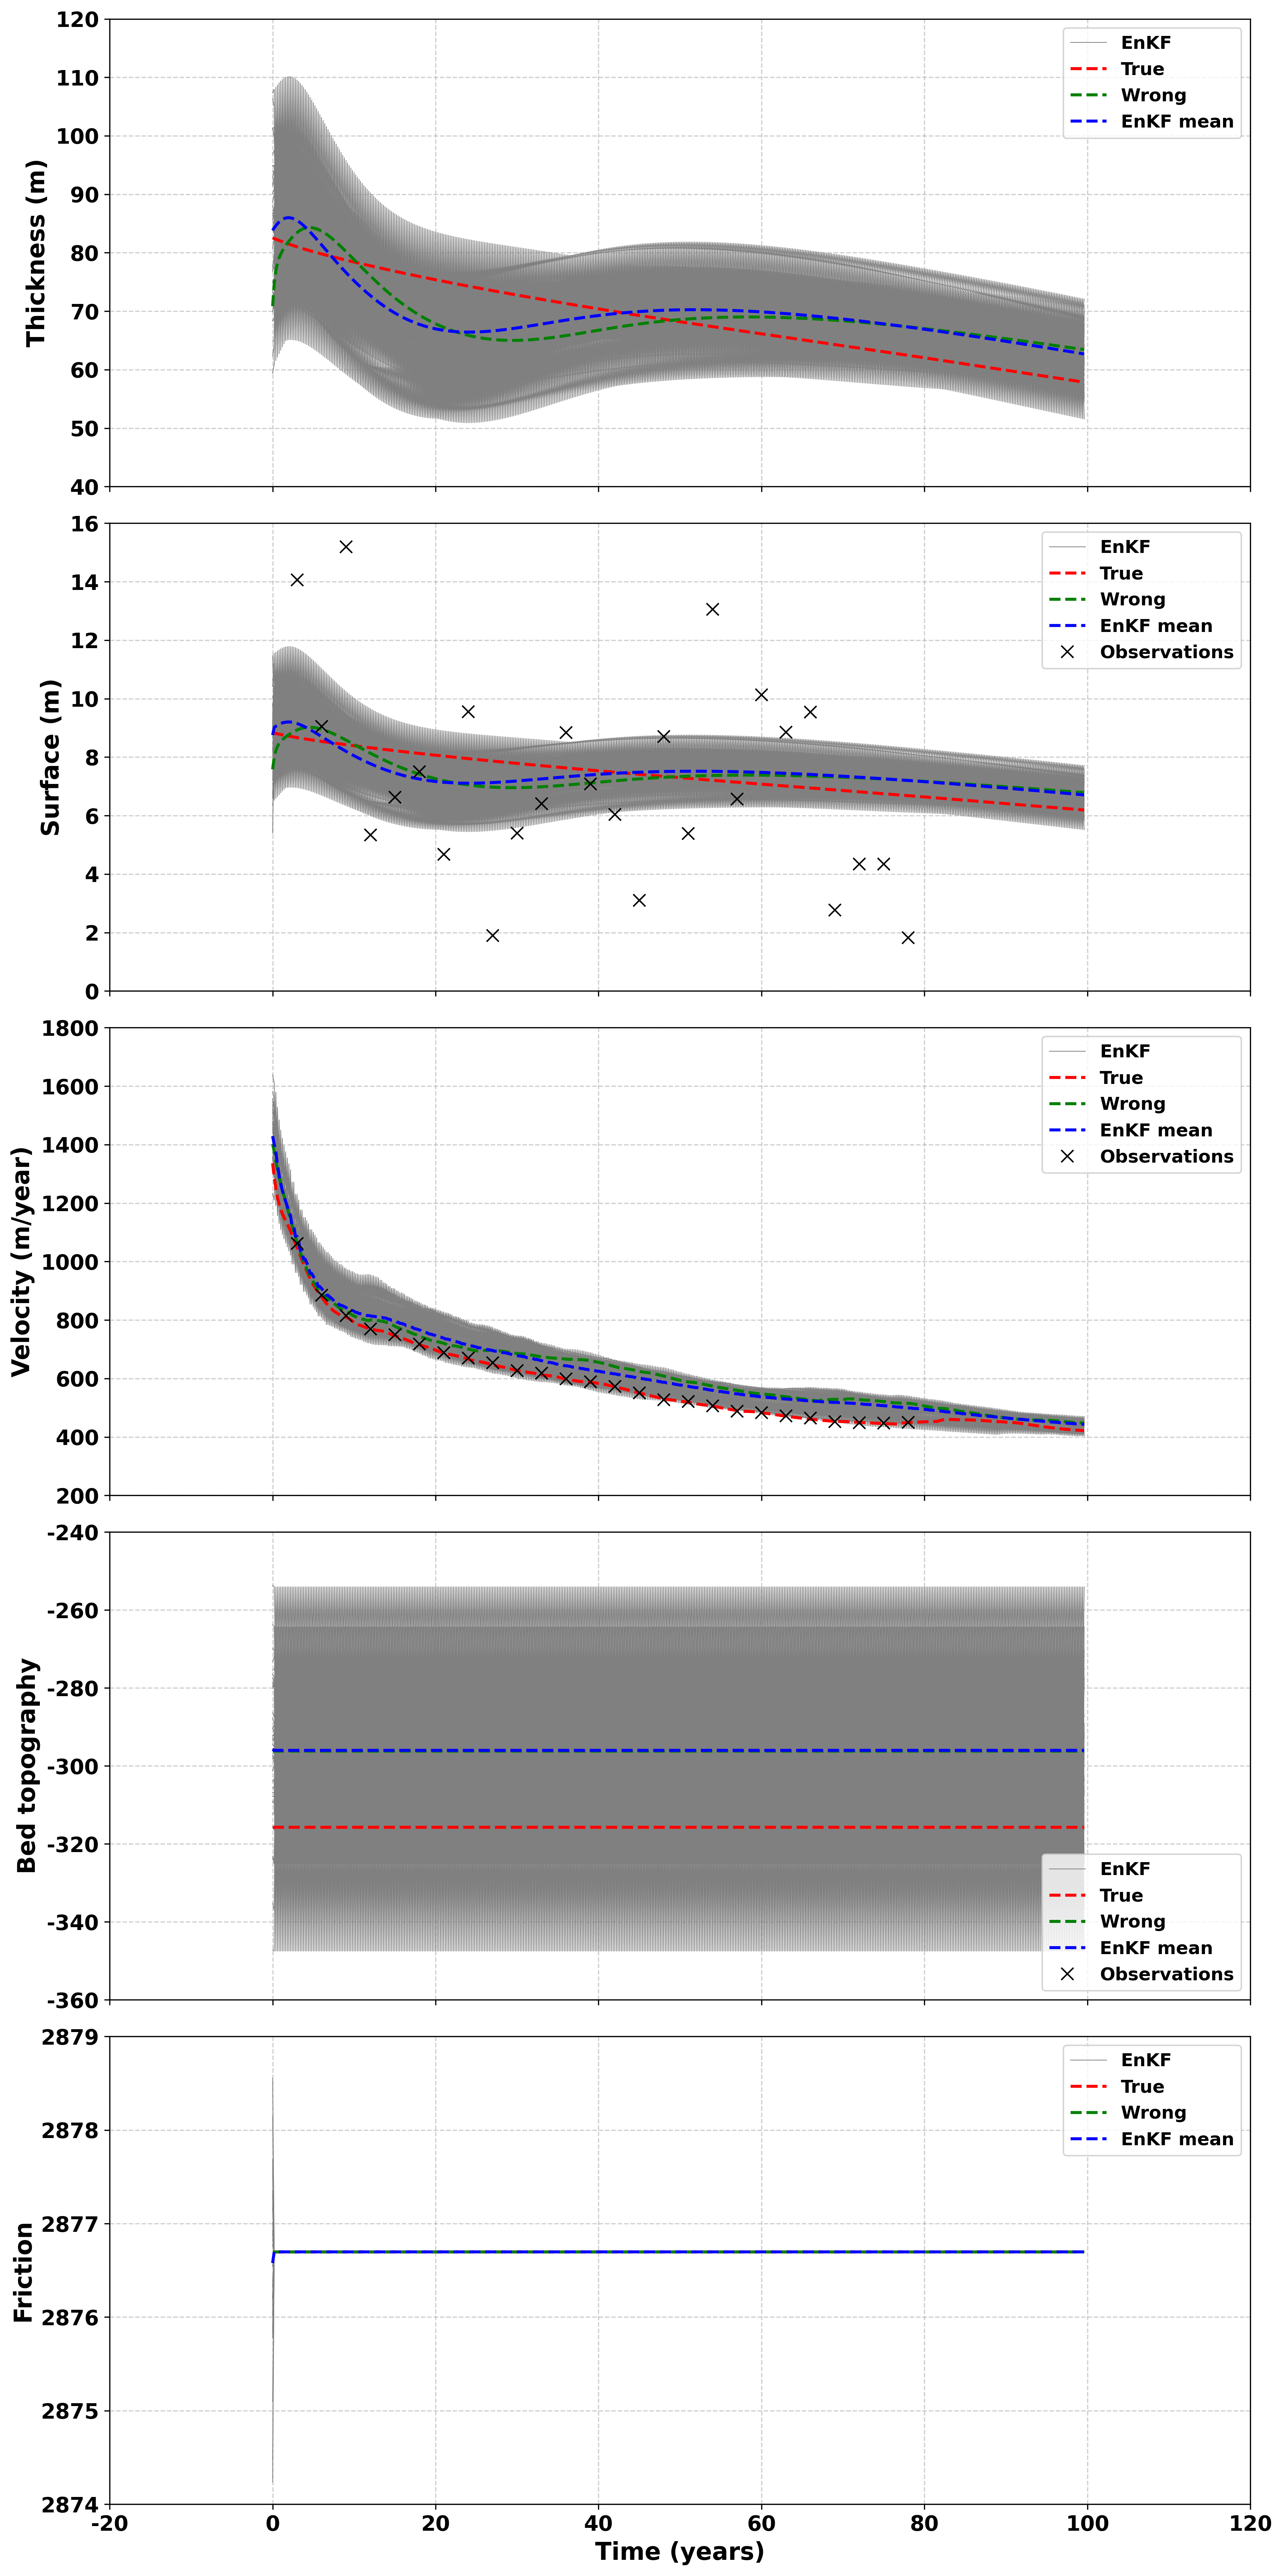

In [41]:
# ------------------------------------------------------------
# Main figure using the generic helpers
# ------------------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(12, 24), dpi=300, sharex=True)
ax_h, ax_s, ax_u, ax_bed, ax_f = axes

# h_indx = hdim - 2            # spatial index
# h_indx = 1000
h_indx=390
_nt = min(499, t.size)       # safety
Nens = ensemble_vec_full.shape[1]

# 1) Thickness (block 0), no thickness obs in w here -> obs_times_idx=None
plot_scalar_block(
    ax=ax_h,
    t=t,
    _nt=_nt,
    hdim=hdim,
    block_id=0,
    h_indx=h_indx,
    w=w,
    ensemble_true_state=ensemble_true_state,
    ensemble_nurged_state=ensemble_nurged_state,
    ensemble_vec_mean=ensemble_vec_mean,
    ensemble_vec_full=ensemble_vec_full,
    Nens=Nens,
    filter_type=filter_type,
    ylabel="Thickness (m)",
    obs_times_idx=None,  # set to ind_m if you later have thickness obs
)

# 2) Surface (block 1) with observations at times ind_m
plot_scalar_block(
    ax=ax_s,
    t=t,
    _nt=_nt,
    hdim=hdim,
    block_id=1,
    h_indx=h_indx,
    w=w,
    ensemble_true_state=ensemble_true_state,
    ensemble_nurged_state=ensemble_nurged_state,
    ensemble_vec_mean=ensemble_vec_mean,
    ensemble_vec_full=ensemble_vec_full,
    Nens=Nens,
    filter_type=filter_type,
    ylabel="Surface (m)",
    obs_times_idx=ind_m,
    obs_mask_zero=False,
)

# 3) Velocity magnitude from (u, v) blocks 2 and 3
plot_velocity_block(
    ax=ax_u,
    t=t,
    _nt=_nt,
    hdim=hdim,
    block_id_u=2,
    block_id_v=3,
    h_indx=h_indx,
    w=w,
    ensemble_true_state=ensemble_true_state,
    ensemble_nurged_state=ensemble_nurged_state,
    ensemble_vec_mean=ensemble_vec_mean,
    ensemble_vec_full=ensemble_vec_full,
    Nens=Nens,
    filter_type=filter_type,
    ylabel="Velocity (m/year)",
    obs_times_idx=ind_m,
)

# 4) Bed (block 4), sparse obs in w with zeros → mask_zero=True
plot_scalar_block(
    ax=ax_bed,
    t=t,
    _nt=_nt,
    hdim=hdim,
    block_id=4,
    h_indx=h_indx,
    w=w,
    ensemble_true_state=ensemble_true_state,
    ensemble_nurged_state=ensemble_nurged_state,
    ensemble_vec_mean=ensemble_vec_mean,
    ensemble_vec_full=ensemble_vec_full,
    Nens=Nens,
    filter_type=filter_type,
    ylabel="Bed topography",
    obs_times_idx=ind_m,
    obs_mask_zero=True,
)

# 5) Friction (block 5), no obs
plot_scalar_block(
    ax=ax_f,
    t=t,
    _nt=_nt,
    hdim=hdim,
    block_id=5,
    h_indx=h_indx,
    w=w,
    ensemble_true_state=ensemble_true_state,
    ensemble_nurged_state=ensemble_nurged_state,
    ensemble_vec_mean=ensemble_vec_mean,
    ensemble_vec_full=ensemble_vec_full,
    Nens=Nens,
    filter_type=filter_type,
    ylabel="Friction",
    obs_times_idx=None,
)

# Label x-axis only on bottom
style_axis(ax_f, ylabel="Friction", xlabel="Time (years)")

fig.tight_layout()
fig.savefig(f"profile_{profile_flag}_time_series.png",
            bbox_inches="tight", dpi=300)
plt.show()

In [21]:
import h5py
with h5py.File('Htest.h5', 'r') as f:
    H = f['H'][:]
    virtual_obs = f['virtual_obs'][:]
    H_virtual_obs = f['H_virtual_obs'][:]

H.max(), H.min()

(np.float64(1.0), np.float64(0.0))

In [22]:
H.shape, virtual_obs.shape, H_virtual_obs.shape

((13388, 20082), (20082,), (13388,))

In [23]:
H[3*12323:,4*12323+12321].shape

IndexError: index 61613 is out of bounds for axis 1 with size 20082

In [ ]:
import os
import h5py
import numpy as np
import gstools as gs

def build_gaussian_friction_field(
    data_dir,
    nd,
    kwargs,
    noise_level=0.25,
):
    """
    Build a Gaussian friction field on the ISSM friction DOFs
    with higher values near upper/lower y and lower in the center.
    Returns a 1D array of length fdim (friction DOFs).
    """

    h5file = os.path.join(data_dir, f"mesh_idxy_{0}.h5")
    with h5py.File(h5file, "r") as f:
        x_param = f["/fric_x"][:]   # (fdim,)
        y_param = f["/fric_y"][:]   # (fdim,)

    fdim = x_param.size

    sill_friction   = kwargs.get("sill_friction", 90000)
    range_friction  = kwargs.get("range_friction", 5000)
    mean_friction   = kwargs.get("mean_friction", 2500.0)
    nugget_friction = kwargs.get("nugget_friction", 0.0)
    seed_base       = kwargs.get("seed_base", 42)
    edge_amplitude  = kwargs.get("edge_amplitude", 2000.0)

    len_x = kwargs.get("len_x", range_friction)
    len_y = kwargs.get("len_y", 10e3)

    # # ==========================================================
    # # 1) Strong deterministic profile: high at edges, low center
    # # ==========================================================
    # y_min = y_param.min()
    # y_max = y_param.max()
    # Ly    = y_max - y_min

    # # y normalized to [0,1]
    # y_norm = (y_param - y_min) / Ly

    # # cos profile: high at y_norm=0 and 1, low at 0.5
    # base_profile = mean_friction + edge_amplitude * np.cos(2.0 * np.pi * y_norm)

    # # ==========================================================
    # # 2) Gaussian random field (texture) – weaker than base
    # # ==========================================================
    # x_scaled = x_param / len_x
    # y_scaled = y_param / len_y

    # model = gs.Gaussian(
    #     dim=2,
    #     var=sill_friction,
    #     len_scale=[1.0, 1.0],
    #     nugget=nugget_friction,
    # )

    # srf = gs.SRF(model, seed=seed_base)
    # noise = np.asarray(srf((x_scaled, y_scaled)))  # (fdim,)

    # # normalize noise
    # noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    # # make noise amplitude tied to edge_amplitude so it’s clearly smaller
    # noise_amp = noise_level * edge_amplitude

    # friction = base_profile + noise_amp * noise

    # # keep positive
    # friction = np.clip(friction, 1e-3, None)

    # return friction
    # correlation lengths (you can override in kwargs)
    len_x_long  = kwargs.get("len_x_long", 80e3)
    len_y_long  = kwargs.get("len_y_long", 15e3)
    len_x_short = kwargs.get("len_x_short", 15e3)
    len_y_short = kwargs.get("len_y_short", 3e3)

    # relative amplitudes for long/short-scale noise
    long_level  = kwargs.get("long_level", 0.25)   # fraction of edge_amplitude
    short_level = kwargs.get("short_level", 0.15)

    # =====================================================
    # 1) Strong deterministic profile: high at edges, low center
    # =====================================================
    y_min = y_param.min()
    y_max = y_param.max()
    Ly    = y_max - y_min

    y_norm = (y_param - y_min) / Ly            # in [0, 1]

    # cos: high at y=0,1; low at y=0.5
    base_profile = mean_friction + edge_amplitude * np.cos(2.0 * np.pi * y_norm)

    # =====================================================
    # 2) Long-scale Gaussian texture
    # =====================================================
    x_scaled_long = x_param / len_x_long
    y_scaled_long = y_param / len_y_long

    model_long = gs.Gaussian(
        dim=2,
        var=sill_friction,
        len_scale=[1.0, 1.0],
        nugget=nugget_friction,
    )
    srf_long = gs.SRF(model_long, seed=seed_base)
    noise_long = np.asarray(srf_long((x_scaled_long, y_scaled_long)))
    noise_long = (noise_long - noise_long.mean()) / (noise_long.std() + 1e-12)

    # =====================================================
    # 3) Short-scale Gaussian texture
    # =====================================================
    x_scaled_short = x_param / len_x_short
    y_scaled_short = y_param / len_y_short

    model_short = gs.Gaussian(
        dim=2,
        var=sill_friction,
        len_scale=[1.0, 1.0],
        nugget=nugget_friction,
    )
    srf_short = gs.SRF(model_short, seed=seed_base + 1)
    noise_short = np.asarray(srf_short((x_scaled_short, y_scaled_short)))
    noise_short = (noise_short - noise_short.mean()) / (noise_short.std() + 1e-12)

    # =====================================================
    # 4) Combine: band + long + short texture
    # =====================================================
    long_amp  = long_level  * edge_amplitude
    short_amp = short_level * edge_amplitude

    friction = (
        base_profile
        + long_amp  * noise_long
        + short_amp * noise_short
    )

    friction = np.clip(friction, 1e-3, None)

    return friction

In [ ]:
def write_friction_field_to_h5(
    data_dir,
    nd,
    kwargs,
    noise_level=0.25,
    dset_name="friction_field",
):
    """
    Build the Gaussian friction field and write it to the main HDF5 file
    under the given dataset name (default: '/friction_field').
    """
    friction_field = build_gaussian_friction_field(
        data_dir=data_dir,
        nd=nd,
        kwargs=kwargs,
        noise_level=noise_level,
    )

    h5file = os.path.join(data_dir, "friction_data.h5")
    with h5py.File(h5file, "a") as f:
        # delete old dataset if it exists
        if dset_name in f:
            del f[dset_name]

        dset = f.create_dataset(
            dset_name,
            data=friction_field,
            dtype="f8",
            compression="gzip",
            shuffle=True,
        )

        # (optional) store some metadata as attributes
        dset.attrs["description"] = "Gaussian friction field with edge-enhanced profile"
        dset.attrs["noise_level"] = noise_level
        dset.attrs["mean_friction"] = kwargs.get("mean_friction", 3000.0)

    return friction_field

In [ ]:
kwargs = {
    # domain (only used if you still read these; safe defaults)
    "Lx": 640e3,
    "Ly": 80e3,
    "nx": 200,
    "ny": 20,

    # friction SRF hyperparameters
    "sill_friction": 90000.0,       # variance of the Gaussian field
    "range_friction": 5000,     # base correlation length scale
    "mean_friction": 2500.0,    # mean basal friction (Pa m^-1 or whatever units)
    "nugget_friction": 0.05,    # small nugget for extra small-scale noise

    # anisotropic correlation lengths (x: long, y: shorter)
    "len_x": 60e3,              # smoother along-flow
    "len_y": 8e3,               # more variation across-flow

    # vertical (y) structure: high at edges, low at center
    "edge_contrast": 2000.0,    # edges ~ mean ± 750 compared to center
    "edge_amplitude": 2000.0,

    # randomness
    "seed_base": 123,           # change for a different realization
    "noise_level": 0.15,         # 0.2–0.4 gives visible but not crazy texture

     # long-scale variations (broad waves along x)
    "len_x_long": 120e3,
    "len_y_long": 20e3,

    # short-scale variations (patches)
    "len_x_short": 20e3,
    "len_y_short": 4e3,

    # amplitudes for textures relative to edge_amplitude
    "long_level": 0.25,    # ~500 units
    "short_level": 0.20,   # ~400 units
}

# somewhere in initialization / ensemble setup
friction_field = write_friction_field_to_h5(
    data_dir=data_dir,
    nd=nd,
    kwargs=kwargs,
    noise_level=kwargs.get("noise_level", 0.25),
)


In [ ]:
import h5py, os
from gstools import Gaussian, krige, Exponential
from pykrige.ok import OrdinaryKriging
import numpy as np

""" kriging with an exponential covariance model to generate a conditional random field of the bed topography constrained by these observations gstools
 """
# conditions: constrained by observations at certain points
data_dir = "_modelrun_datasets"
with h5py.File(f'{data_dir}/synthetic_obs.h5','r') as f:
    w = f['hu_obs'][:]
    ndim = w.shape[0]//6
    bed_obs = w[4*ndim:5*ndim,:]  # bed observations

# file_path = f'{icesee_path}/{data_path}/mesh_idxy_{0}.h5'
file_path = os.path.join(data_dir, f"mesh_idxy_{0}.h5")
with h5py.File(file_path, 'r') as f:
    x_param = f['/fric_x'][:]   # shape (fdim,)
    y_param = f['/fric_y'][:]   # shape (fdim,)

sill_bed = 4000            # Sill bedrock elevation (4000 m from paper)
range_bed = 50000          # Range bedrock elevation (50000 m from paper)
nugget_bed = 200           # Nugget effect for bedrock elevation (200

cov_model = Exponential(
    dim=2,
    var=sill_bed,
    len_scale=range_bed,
    nugget=nugget_bed,
)

# conditions should be points for which bed observations are available (non-zero)  
mask = bed_obs != 0  
cond_vals = bed_obs[mask]  # observed bed values (non-zero)
cond_pos = np.where(mask)[0]  # indices of observed bed values

# krig = krige.Ordinary(cov_model, cond_pos, cond_vals, exact=True)
# bed_kriged = krig(x_param, y_param)  # kriged bed topography at all points
# ax = krig.plot()

# try using pykrige
OK = OrdinaryKriging(
    x_param[cond_pos],
    y_param[cond_pos],
    cond_vals,
    cov_model
)
z1, ss1, = OK.execute('grid', x_param, y_param)
import matplotlib.pyplot as plt
plt.imshow(z1.T, origin='lower')

In [ ]:
import h5py, os
from gstools import Gaussian, krige, Exponential
import numpy as np

# conditions: constrained by observations at certain points
data_dir = "_modelrun_datasets"
with h5py.File(f'{data_dir}/synthetic_obs.h5','r') as f:
    w = f['hu_obs'][:]
    ndim = w.shape[0] // 6
    bed_obs = w[4*ndim:5*ndim, :]  # shape (ndim, n_times)

file_path = os.path.join(data_dir, "mesh_idxy_0.h5")
with h5py.File(file_path, 'r') as f:
    x_param = f['/fric_x'][:]   # shape (ndim,)
    y_param = f['/fric_y'][:]   # shape (ndim,)

sill_bed = 4000            # Sill bedrock elevation (m)
range_bed = 50000          # Range bedrock elevation (m)
nugget_bed = 200           # Nugget effect for bedrock elevation (m^2)

cov_model = Exponential(
    dim=2,
    var=sill_bed,
    len_scale=range_bed,
    nugget=nugget_bed,
)

# ---- choose a single bed field to condition on ----
bed_field = bed_obs[:, 0]          # or bed_obs[:, -1], or a mean over time
mask = bed_field != 0.0            # only locations where bed is observed

cond_vals = bed_field[mask]        # observed bed values (non-zero)
cond_x = x_param[mask]
cond_y = y_param[mask]

# gstools: cond_pos must be shape (2, n_points)
cond_pos = np.vstack([cond_x, cond_y])

# ---- kriging ----
krig = krige.Ordinary(cov_model, cond_pos, cond_vals, exact=True)
bed_kriged = krig(x_param, y_param)  # kriged bed topography at all points

ax = krig.plot()

In [ ]:
from pykrige.ok import OrdinaryKriging

In [6]:
import h5py
import gstools as gs
import numpy as np
icesee_path='/Users/bkyanjo3/da_project/ICESEE/applications/issm_model/examples/ISMIP_Choi'
data_path='_modelrun_datasets'
sill_friction = 1000.0       # variance of the Gaussian field
range_friction  = 500     # base correlation length scale
nugget_friction = 0.15    # small nugget for extra small-scale noise
seed_base       = 123           # change for a different realization
file_path = f'{icesee_path}/{data_path}/mesh_idxy_{0}.h5'
with h5py.File(file_path, 'r') as f:
    x_param = f['/fric_x'][:]   # shape (fdim,)
    y_param = f['/fric_y'][:]   # shape (fdim,)

# scale coords by correlation length so len_scale ~ 1
x_scaled = x_param / range_friction
y_scaled = y_param / range_friction

model = gs.Gaussian(
    dim=2,
    var=sill_friction,
    len_scale=range_friction,
    nugget=nugget_friction,
)

srf = gs.SRF(model, seed=seed_base)

# unstructured evaluation at real node positions
# friction_field = np.asarray(srf((x_scaled, y_scaled)))  # (fdim,)
friction_field = np.asarray(srf((x_param, y_param)))  # (fdim,)

sill_bed = 5000            # Sill bedrock elevation (m)
range_bed = 30000          # Range bedrock elevation (m)
nugget_bed = 100           # Nugget effect for bedrock elevation (m)
model_bed = gs.Exponential(
        dim=2,
        var=sill_bed,
        len_scale=range_bed,
        nugget=nugget_bed,
    )
srf_bed = gs.SRF(model_bed, seed=seed_base)
# unstructured evaluation at real node positions
# bed_field = np.asarray(srf_bed((x_param / range_bed, y_param / range_bed)))  # (fdim,)
bed_field = np.asarray(srf_bed((x_param, y_param)))  # (fdim,)


ens_id = 0;
friction_bed_filename = f'{icesee_path}/{data_path}/friction_bed_{ens_id}.h5'
with h5py.File(friction_bed_filename, 'w') as f:
    # -- write the friction field
    f.create_dataset('coefficient', data=friction_field)
    # -- write the bed field
    # f.create_dataset('bed', data=bed_field)

print(max(friction_field), min(friction_field)
      , max(bed_field), min(bed_field))



113.48917841546042 -123.90624780687646 183.749181151747 -175.55921542724334


In [24]:
import numpy as np
import gstools as gs
from gstools import krige
import h5py

icesee_path='/Users/bkyanjo3/da_project/ICESEE/applications/issm_model/examples/ISMIP_Choi'
data_path='_modelrun_datasets'

# Node coordinates, 1D
file_path = f"{icesee_path}/{data_path}/mesh_idxy_{0}.h5"
with h5py.File(file_path, "r") as f:
    x_param = f["/fric_x"][:]   # shape (fdim,)
    y_param = f["/fric_y"][:]   # shape (fdim,)

x = np.asarray(x_param).ravel()   # meters
y = np.asarray(y_param).ravel()   # meters
npts = x.size

# True state
fpath = f"{icesee_path}/{data_path}/true_nurged_states.h5"
with h5py.File(fpath, "r") as f:
    w = f["true_state"][:]        # shape (6*ndim, nt)

ndim = w.shape[0] // 6
nt   = w.shape[1]

# bed_true_all: (ndim, nt)
bed_true_all = w[4*ndim:5*ndim, :]

# ---- choose ONE snapshot in time ----
snap_idx = 0          # or whatever time index you want (0..nt-1)
bed_true = bed_true_all[:, snap_idx]   # shape (ndim,)

# sanity check
assert bed_true.shape[0] == npts, f"bed_true({bed_true.shape[0]}) != npts({npts})"

# Convert to km for spacing logic
x_km = x / 1000.0
y_km = y / 1000.0

# Tracks PERPENDICULAR to ice flow (flow along x → tracks at fixed x)
stride_km = 7.0

x_min, x_max = x_km.min(), x_km.max()
track_xs = np.arange(x_min, x_max + 1e-6, stride_km)

if track_xs.size > 1:
    dx_nom = (x_max - x_min) / (track_xs.size - 1)
else:
    dx_nom = stride_km
band = 0.5 * dx_nom   # km

# Build mask of nodes that lie "on" a radar track
obs_mask = np.zeros(npts, dtype=bool)
for x_line in track_xs:
    obs_mask |= np.abs(x_km - x_line) <= band

print("Radar-bed obs points:", obs_mask.sum(), "out of", npts)

# Synthetic radar observations = true bed + noise
sigma_noise = 20.0  # m, adjust as you like

x_obs = x[obs_mask]
y_obs = y[obs_mask]
z_obs = bed_true[obs_mask] + sigma_noise * np.random.randn(obs_mask.sum())

# ---- kriging model ----
sill_bed   = 5000.0    # variance [m^2]
range_bed  = 50000.0   # correlation length [m]
nugget_bed = 200.0     # measurement error / nugget [m^2]

model_bed = gs.Exponential(
    dim=2,
    var=sill_bed,
    len_scale=range_bed,
    nugget=nugget_bed,
)

# Ordinary kriging conditioned on radar tracks
ok_bed = krige.Ordinary(
    model_bed,
    cond_pos=[x_obs, y_obs],
    cond_val=z_obs,
)

# Kriged mean + variance at all nodes
bed_kriged, bed_var = ok_bed([x, y], return_var=True)
bed_kriged = np.asarray(bed_kriged)

# Conditional random field for ensemble
cond_srf_bed = gs.CondSRF(ok_bed)

def draw_bed_realization(seed):
    field = cond_srf_bed([x, y], seed=seed)
    return np.asarray(field)

Ne = 60
bed_ens = np.zeros((Ne, npts))
for e in range(Ne):
    bed_ens[e, :] = draw_bed_realization(seed=1234 + e)

with h5py.File("bed_kriging_results.h5", "w") as f:
    f.create_dataset("x", data=x)
    f.create_dataset("y", data=y)
    f.create_dataset("bed_true", data=bed_true)
    f.create_dataset("obs_mask", data=obs_mask)
    f.create_dataset("z_obs", data=z_obs)
    f.create_dataset("bed_kriged", data=bed_kriged)
    f.create_dataset("bed_var", data=bed_var)
    f.create_dataset("bed_ens", data=bed_ens)

Radar-bed obs points: 3347 out of 3347


In [22]:
bed_ens.shape  # (Ne, npts)
with h5py.File("bed_kriging_results.h5", "w") as f:
    f.create_dataset("x", data=x)
    f.create_dataset("y", data=y)
    f.create_dataset("bed_true", data=bed_true)
    f.create_dataset("obs_mask", data=obs_mask)
    f.create_dataset("z_obs", data=z_obs)
    f.create_dataset("bed_kriged", data=bed_kriged)
    f.create_dataset("bed_var", data=bed_var)
    f.create_dataset("bed_ens", data=bed_ens)
    

In [ ]:
with h5py.File("bed_kriging_results.h5", "r") as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")

(np.float64(492.1730363123407), np.float64(-1297.1308303078215))

In [27]:
max(np.mean(bed_ens.T, axis=1)), min(np.mean(bed_ens.T, axis=1))


(np.float64(478.2134350213421), np.float64(-1266.825137210248))

In [48]:
import numpy as np
a = np.array([1,2])
# extend to five columes
b = np.tile(a, (1,5))
b.shape

(1, 10)

In [49]:
b

array([[1, 2, 1, 2, 1, 2, 1, 2, 1, 2]])

In [10]:
import re
vec = ['Bed', 'u',' v']
if any(re.search('bed', s, re.IGNORECASE) for s in vec):
    print('found bed')

if re.match(r'bed', vec[0], re.IGNORECASE):
    print('matched bed')

found bed
matched bed
